# Activity: Understanding Multi-Layer Perceptrons (MLPs)

### Exercise 1: Manual Calculation of MLP Steps

Consider a simple MLP with 2 input features, 1 hidden layer containing 2 neurons, and 1 output neuron. Use the hyperbolic tangent (tanh) function as the activation for both the hidden layer and the output layer. The loss function is mean squared error (MSE):  
$L = \frac{1}{N}(y - \hat{y})^2$
where $\hat{y}$ is the network’s output.

For this exercise, use the following specific values:

- **Input and output vectors:**
  $$
  \mathbf{x} = [0.5, -0.2]
  $$
  $$
  y = 1.0
  $$

- **Hidden layer weights:**
  $$
  \mathbf{W}^{(1)} =
  \begin{bmatrix}
  0.3 & -0.1 \\
  0.2 & 0.4
  \end{bmatrix}
  $$

- **Hidden layer biases:**
  $$
  \mathbf{b}^{(1)} = [0.1, -0.2]
  $$

- **Output layer weights:**
  $$
  \mathbf{W}^{(2)} = [0.5, -0.3]
  $$

- **Output layer bias:**
  $$
  b^{(2)} = 0.2
  $$

- **Learning rate:** $\eta = 0.3$

- **Activation function:** $tanh$

---

Perform the following steps explicitly, showing all mathematical derivations and calculations with the provided values:
### 1. Forward Pass:
- Compute the hidden layer pre-activations:  
  $
  z^{(1)} = W^{(1)}x + b^{(1)}
  $
- Apply tanh to get hidden activations:  
  $
  h^{(1)} = \tanh(z^{(1)})
  $
- Compute the output pre-activation:  
  $
  u^{(2)} = W^{(2)}h^{(1)} + b^{(2)}
  $
- Compute the final output:  
  $
  \hat{y} = \tanh(u^{(2)})
  $

---

### 2. Loss Calculation:
- Compute the MSE loss:  
  $
  L = \frac{1}{N}(y - \hat{y})^2
  $

---

### 3. Backward Pass (Backpropagation):  
Compute the gradients of the loss with respect to all weights and biases.  
Start with $\frac{\partial L}{\partial \hat{y}}$, then compute:

- $\frac{\partial L}{\partial u^{(2)}}$ (using the tanh derivative:  
  $
  \frac{d}{du}\tanh(u) = 1 - \tanh^2(u)
  $
  )

- **Gradients for output layer:**  
  $
  \frac{\partial L}{\partial W^{(2)}}, \quad \frac{\partial L}{\partial b^{(2)}}
  $

- **Propagate to hidden layer:**  
  $
  \frac{\partial L}{\partial h^{(1)}}, \quad \frac{\partial L}{\partial z^{(1)}}
  $

- **Gradients for hidden layer:**  
  $
  \frac{\partial L}{\partial W^{(1)}}, \quad \frac{\partial L}{\partial b^{(1)}}
  $

Show all intermediate steps and calculations.

---

### 4. Parameter Update:  
Using the learning rate $\eta = 0.1$, update all weights and biases via gradient descent:

$
W^{(2)} \leftarrow W^{(2)} - \eta \frac{\partial L}{\partial W^{(2)}}
$

$
b^{(2)} \leftarrow b^{(2)} - \eta \frac{\partial L}{\partial b^{(2)}}
$

$
W^{(1)} \leftarrow W^{(1)} - \eta \frac{\partial L}{\partial W^{(1)}}
$

$
b^{(1)} \leftarrow b^{(1)} - \eta \frac{\partial L}{\partial b^{(1)}}
$

Provide the numerical values for all updated parameters.

---

**Submission Requirements:**  
Show all mathematical steps explicitly, including intermediate calculations (e.g., matrix multiplications, tanh applications, gradient derivations). Use exact numerical values throughout and avoid rounding excessively to maintain precision (at least 4 decimal places).


In [8]:
# Inicialização 

import numpy as np

# Vetor de entrada e saída esperada
x = np.array([[0.5],[-0.2]]) # x1 e x2
y = 1.0  # target

# Pesos e bias da camada oculta (hidden layer)
W1 = np.array([[0.3, -0.1],   # conexões para neurônio h1
            [0.2,  0.4]])  # conexões para neurônio h2
b1 = np.array([[0.1],         # bias do h1
            [-0.2]])       # bias do h2

# Pesos e bias da camada de saída
W2 = np.array([[0.5, -0.3]])  # conecta h1 e h2 ao neurônio de saída
b2 = 0.2                      # bias do neurônio de saída

# aprendizado
eta = 0.3

# Função de ativação: tanh
def tanh(z):
    return np.tanh(z)

def tanh_linha(z):
    return 1 - np.tanh(z)**2



## Forward Pass

$$
z^{(1)} = W^{(1)}x + b^{(1)} =
\begin{bmatrix}
0.3 & -0.1 \\
0.2 & 0.4
\end{bmatrix}
\cdot
\begin{bmatrix}
0.5 \\ -0.2
\end{bmatrix}
+
\begin{bmatrix}
0.1 \\ -0.2
\end{bmatrix}
=
\begin{bmatrix}
0.27 \\ -0.18
\end{bmatrix}
$$

$$
h^{(1)} = \tanh(z^{(1)}) = 
\begin{bmatrix}
0.2636 \\ -0.1781
\end{bmatrix}
$$

$$
u^{(2)} = W^{(2)}h^{(1)} + b^{(2)} = 
[0.5 \; -0.3]
\cdot
\begin{bmatrix}
0.2636 \\ -0.1781
\end{bmatrix}
+ 0.2 = 0.3852
$$

$$
\hat{y} = \tanh(u^{(2)}) = 0.3672
$$

In [13]:
# ==========================
# Forward Pass
# ==========================

# 1. Hidden layer pre-activation: z^(1) = W1 * x + b1
z1 = np.dot(W1, x) + b1
print("z^(1):\n", z1)

# 2. Hidden layer activation: h^(1) = tanh(z^(1))
h1 = tanh(z1)
print("h^(1):\n", h1)

# 3. Output pre-activation: u^(2) = W2 * h^(1) + b2
u2 = np.dot(W2, h1) + b2
print("u^(2):", u2)

# 4. Final output: y_hat = tanh(u^(2))
y_prev = tanh(u2)
print("y_previsto (final output):", y_prev)


z^(1):
 [[ 0.27]
 [-0.18]]
h^(1):
 [[ 0.26362484]
 [-0.17808087]]
u^(2): [[0.38523668]]
y_previsto (final output): [[0.36724656]]


## Loss

$$
L = (y - \hat{y})^2 = (1 - 0.3672)^2 = 0.4003
$$

In [14]:
# ==========================
# Loss Calculation (MSE)
# ==========================

# Como temos apenas 1 exemplo, N = 1
N = 1
L = (1/N) * (y - y_prev)**2
print("Loss (MSE):", L)


Loss (MSE): [[0.40037691]]


## Backward Pass

1. Loss em relação à saída:

$$
\frac{\partial L}{\partial \hat{y}} = -2(y - \hat{y})
$$

2. Saída em relação ao pré-ativação:

$$
\frac{\partial L}{\partial u^{(2)}} =
\frac{\partial L}{\partial \hat{y}}
\cdot (1 - \tanh^2(u^{(2)}))
$$

3. Gradientes da camada de saída:

$$
\frac{\partial L}{\partial W^{(2)}} = \frac{\partial L}{\partial u^{(2)}} \cdot h^{(1)T}
$$

$$
\frac{\partial L}{\partial b^{(2)}} = \frac{\partial L}{\partial u^{(2)}}
$$

4. Propagação para hidden:

$$
\frac{\partial L}{\partial h^{(1)}} = (W^{(2)})^T \cdot \frac{\partial L}{\partial u^{(2)}}
$$

$$
\frac{\partial L}{\partial z^{(1)}} = \frac{\partial L}{\partial h^{(1)}} \odot (1 - \tanh^2(z^{(1)}))
$$

5. Gradientes da camada oculta:

$$
\frac{\partial L}{\partial W^{(1)}} = \frac{\partial L}{\partial z^{(1)}} \cdot x^T
$$

$$
\frac{\partial L}{\partial b^{(1)}} = \frac{\partial L}{\partial z^{(1)}}
$$

In [15]:
# ==========================
# Backward Pass (Backpropagation)
# ==========================

# 1. Derivada da loss em relação à saída
dL_dyprev = -2 * (y - y_prev)

# 2. Derivada em relação a u^(2)
dL_du2 = dL_dyprev * tanh_linha(u2)

# 3. Gradientes da camada de saída
dL_dW2 = np.dot(dL_du2, h1.T)   # shape (1,2)
dL_db2 = dL_du2                 # escalar

# 4. Propagar para hidden layer
dL_dh1 = np.dot(W2.T, dL_du2)   # shape (2,1)
dL_dz1 = dL_dh1 * tanh_linha(z1)  # elementwise

# 5. Gradientes da hidden layer
dL_dW1 = np.dot(dL_dz1, x.T)    # shape (2,2)
dL_db1 = dL_dz1                 # shape (2,1)

# Mostrar gradientes
print("dL/dW2:\n", dL_dW2)
print("dL/db2:", dL_db2)
print("dL/dW1:\n", dL_dW1)
print("dL/db1:\n", dL_db1)


dL/dW2:
 [[-0.28862383  0.19496791]]
dL/db2: [[-1.09482791]]
dL/dW1:
 [[-0.25468488  0.10187395]
 [ 0.15901618 -0.06360647]]
dL/db1:
 [[-0.50936975]
 [ 0.31803236]]


## Parameter Update

$$
W^{(2)} \leftarrow W^{(2)} - \eta \frac{\partial L}{\partial W^{(2)}}
$$

$$
b^{(2)} \leftarrow b^{(2)} - \eta \frac{\partial L}{\partial b^{(2)}}
$$

$$
W^{(1)} \leftarrow W^{(1)} - \eta \frac{\partial L}{\partial W^{(1)}}
$$

$$
b^{(1)} \leftarrow b^{(1)} - \eta \frac{\partial L}{\partial b^{(1)}}
$$

In [16]:
# Parameter Update

# Taxa de aprendizado (do enunciado dessa etapa)
eta = 0.1

# Atualização dos parâmetros
W2_new = W2 - eta * dL_dW2
b2_new = b2 - eta * dL_db2

W1_new = W1 - eta * dL_dW1
b1_new = b1 - eta * dL_db1

# Mostrar resultados
print("Updated W2:\n", W2_new)
print("Updated b2:\n", b2_new)
print("Updated W1:\n", W1_new)
print("Updated b1:\n", b1_new)


Updated W2:
 [[ 0.52886238 -0.31949679]]
Updated b2:
 [[0.30948279]]
Updated W1:
 [[ 0.32546849 -0.1101874 ]
 [ 0.18409838  0.40636065]]
Updated b1:
 [[ 0.15093698]
 [-0.23180324]]


# Exercise 2: Binary Classification with Synthetic Data and Scratch MLP

Using the `make_classification` function from scikit-learn, generate a synthetic dataset with the following specifications:

- Number of samples: 1000

- Number of classes: 2

- Number of clusters per class: Use the `n_clusters_per_class` parameter creatively to achieve 1 cluster for one class and 2 for the other (hint: you may need to generate subsets separately and combine them, as the function applies the same number of clusters to all classes by default).

- Other parameters: Set `n_features=2` for easy visualization, `n_informative=2`, `n_redundant=0`, `random_state=42` for reproducibility, and adjust `class_sep` or `flip_y` as needed for a challenging but separable dataset.



Implement an MLP from scratch (without using libraries like TensorFlow or PyTorch for the model itself; you may use NumPy for array operations) to classify this data. You have full freedom to choose the architecture, including:

- Number of hidden layers (at least 1)

- Number of neurons per layer

- Activation functions (e.g., sigmoid, ReLU, tanh)

- Loss function (e.g., binary cross-entropy)

- Optimizer (e.g., gradient descent, with a chosen learning rate)

---

## Steps to follow:

1. Generate and split the data into training (80%) and testing (20%) sets.
2. Implement the forward pass, loss computation, backward pass, and parameter updates in code.
3. Train the model for a reasonable number of epochs (e.g., 100–500), tracking training loss.
4. Evaluate on the test set: Report accuracy, and optionally plot decision boundaries or confusion matrix.
5. Submit your code and results, including any visualizations.

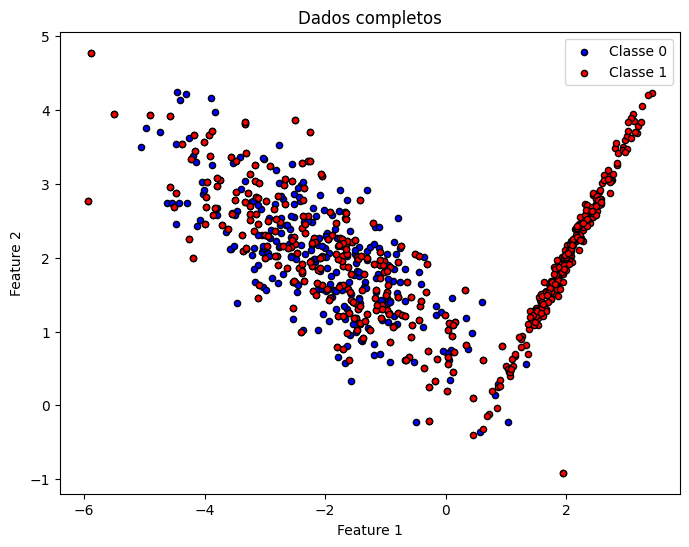

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Geração dos dados 


# Classe 0 -> 1 cluster
X0, y0 = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, n_classes=1, class_sep=2.0, random_state=42
)
y0 = np.zeros_like(y0)  # rótulo 0

# Classe 1 -> 2 clusters
X1, y1 = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=2, n_classes=1, class_sep=2.0, random_state=42
)
y1 = np.ones_like(y1)  # rótulo 1

# Junta os datasets
X = np.vstack((X0, X1))
y = np.hstack((y0, y1)).reshape(-1, 1)

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Plot de todo o dataset
plt.figure(figsize=(8,6))
plt.scatter(X[y.ravel()==0, 0], X[y.ravel()==0, 1], color="blue", s=20, edgecolors='k', label="Classe 0")
plt.scatter(X[y.ravel()==1, 0], X[y.ravel()==1, 1], color="red", s=20, edgecolors='k', label="Classe 1")
plt.title("Dados completos")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()



Epoch 0, Loss: 0.6932
Epoch 20, Loss: 0.6931
Epoch 40, Loss: 0.6930
Epoch 60, Loss: 0.6928
Epoch 80, Loss: 0.6924
Epoch 100, Loss: 0.6916
Epoch 120, Loss: 0.6899
Epoch 140, Loss: 0.6865
Epoch 160, Loss: 0.6803
Epoch 180, Loss: 0.6705
Epoch 200, Loss: 0.6583
Epoch 220, Loss: 0.6457
Epoch 240, Loss: 0.6340
Epoch 260, Loss: 0.6223
Epoch 280, Loss: 0.6098


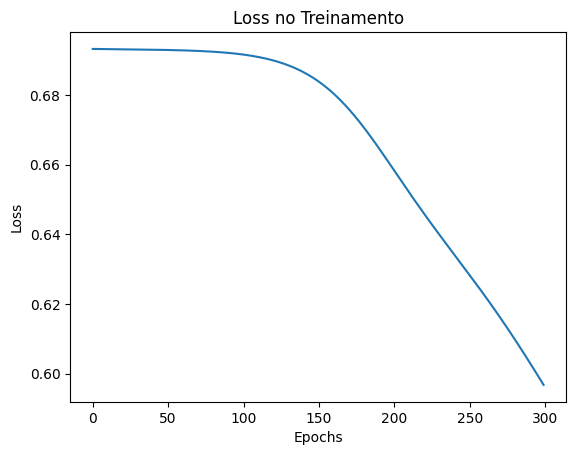

Accuracy no teste: 0.72


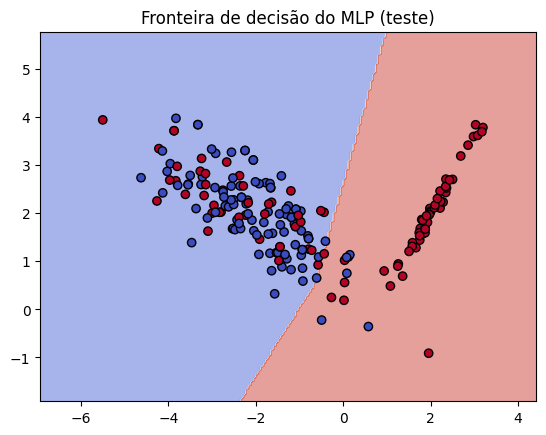

In [2]:
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.01):
        # Inicialização dos pesos
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.01
        self.b2 = np.zeros((1, output_dim))
        self.lr = lr

    # Funções de ativação
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_deriv(self, a):
        return a * (1 - a)

    def relu(self, z):
        return np.maximum(0, z)
    
    def relu_deriv(self, z):
        return (z > 0).astype(float)

    # Forward pass
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    # Loss: Binary Cross-Entropy
    def compute_loss(self, y, y_hat):
        m = y.shape[0]
        return -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))

    # Backpropagation
    def backward(self, X, y):
        m = X.shape[0]

        dZ2 = self.A2 - y
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_deriv(self.Z1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # Atualização dos pesos
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    # Treinamento
    def fit(self, X, y, epochs=200):
        losses = []
        for epoch in range(epochs):
            y_hat = self.forward(X)
            loss = self.compute_loss(y, y_hat)
            self.backward(X, y)
            losses.append(loss)

            if epoch % 20 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        return losses

    # Predição
    def predict(self, X):
        y_hat = self.forward(X)
        return (y_hat > 0.5).astype(int)

# ======================================
# 3. Treinamento do modelo
# ======================================

mlp = MLP(input_dim=2, hidden_dim=8, output_dim=1, lr=0.05)
losses = mlp.fit(X_train, y_train, epochs=300)

# Plot da curva de perda
plt.plot(losses)
plt.title("Loss no Treinamento")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# ======================================
# 4. Avaliação
# ======================================

y_pred = mlp.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy no teste: {accuracy:.2f}")

# ======================================
# 5. Visualização da fronteira de decisão
# ======================================
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test.ravel(), cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("Fronteira de decisão do MLP (teste)")
plt.show()

# Exercise 3: Multi-Class Classification with Synthetic Data and Reusable MLP
Similar to Exercise 2, but with increased complexity.

Use `make_classification` to generate a synthetic dataset with:

- Number of samples: 1500

- Number of classes: 3

- Number of features: 4

- Number of clusters per class: Achieve 2 clusters for one class, 3 for another, and 4 for the last (again, you may need to generate subsets separately and combine them, as the function doesn't directly support varying clusters per class).

- Other parameters: `n_features=4`, `n_informative=4`, `n_redundant=0`, `random_state=42`.

Implement an MLP from scratch to classify this data. You may choose the architecture freely, but for an extra point (bringing this exercise to 4 points), reuse the exact same MLP implementation code from Exercise 2, modifying only hyperparameters (e.g., output layer size for 3 classes, loss function to categorical cross-entropy if needed) without changing the core structure.

Steps:

1. Generate and split the data (80/20 train/test).

2. Train the model, tracking loss.

3. Evaluate on test set: Report accuracy, and optionally visualize (e.g., scatter plot of data with predicted labels).

4. Submit code and results.


Epoch 0, Loss: 1.1978, Train Acc: 0.3267
Epoch 20, Loss: 0.8402, Train Acc: 0.6133
Epoch 40, Loss: 0.7705, Train Acc: 0.6375
Epoch 60, Loss: 0.7305, Train Acc: 0.6558
Epoch 80, Loss: 0.7025, Train Acc: 0.6708
Epoch 100, Loss: 0.6817, Train Acc: 0.6858
Epoch 120, Loss: 0.6648, Train Acc: 0.7008
Epoch 140, Loss: 0.6508, Train Acc: 0.7108
Epoch 160, Loss: 0.6388, Train Acc: 0.7183
Epoch 180, Loss: 0.6286, Train Acc: 0.7267
Epoch 200, Loss: 0.6195, Train Acc: 0.7342
Epoch 220, Loss: 0.6112, Train Acc: 0.7417
Epoch 240, Loss: 0.6031, Train Acc: 0.7475
Epoch 260, Loss: 0.5955, Train Acc: 0.7492
Epoch 280, Loss: 0.5883, Train Acc: 0.7558
Epoch 300, Loss: 0.5815, Train Acc: 0.7600
Epoch 320, Loss: 0.5753, Train Acc: 0.7600
Epoch 340, Loss: 0.5696, Train Acc: 0.7667
Epoch 360, Loss: 0.5643, Train Acc: 0.7675
Epoch 380, Loss: 0.5590, Train Acc: 0.7692
Epoch 400, Loss: 0.5541, Train Acc: 0.7733
Epoch 420, Loss: 0.5495, Train Acc: 0.7758
Epoch 440, Loss: 0.5449, Train Acc: 0.7775
Epoch 460, Loss: 

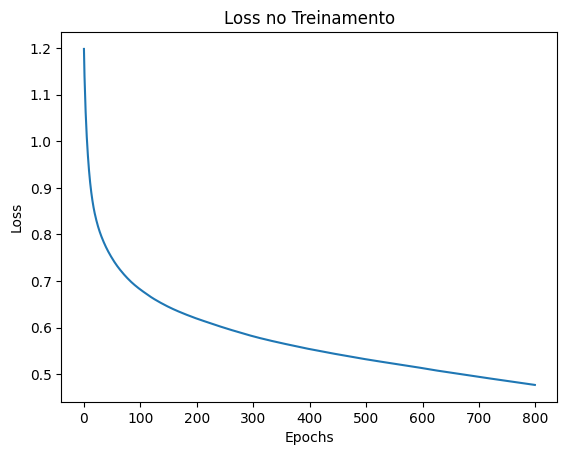

Accuracy no teste: 0.74


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Geração dos dados (3 classes, clusters diferentes)

# Classe 0 - 2 clusters
X0, y0 = make_classification(
    n_samples=500, n_features=4, n_informative=4, n_redundant=0,
    n_clusters_per_class=2, n_classes=1, random_state=42
)
y0 = np.zeros((500, 1))  # classe 0

# Classe 1 - 3 clusters
X1, y1 = make_classification(
    n_samples=500, n_features=4, n_informative=4, n_redundant=0,
    n_clusters_per_class=3, n_classes=1, random_state=42
)
y1 = np.ones((500, 1))  # classe 1

# Classe 2 - 4 clusters
X2, y2 = make_classification(
    n_samples=500, n_features=4, n_informative=4, n_redundant=0,
    n_clusters_per_class=4, n_classes=1, random_state=42
)
y2 = np.full((500, 1), 2)  # classe 2

# Junta tudo
X = np.vstack((X0, X1, X2))
y = np.vstack((y0, y1, y2))

# One-hot encoding dos rótulos
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)


# Mesmo MLP criado anteriormente

class MLP:
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, lr=0.01):
        self.W1 = np.random.randn(input_dim, hidden_dim1) / np.sqrt(input_dim)
        self.b1 = np.zeros((1, hidden_dim1))

        self.W2 = np.random.randn(hidden_dim1, hidden_dim2) / np.sqrt(hidden_dim1)
        self.b2 = np.zeros((1, hidden_dim2))

        self.W3 = np.random.randn(hidden_dim2, output_dim) / np.sqrt(hidden_dim2)
        self.b3 = np.zeros((1, output_dim))

        self.lr = lr

    # Ativações
    def relu(self, z):
        return np.maximum(0, z)
    
    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # Forward pass
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.relu(self.Z2)

        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.softmax(self.Z3)

        return self.A3

    # Loss: Categorical Cross-Entropy
    def compute_loss(self, y, y_hat):
        m = y.shape[0]
        return -np.mean(np.sum(y * np.log(y_hat + 1e-8), axis=1))

    # Backpropagation
    def backward(self, X, y):
        m = X.shape[0]

        # Saída
        dZ3 = self.A3 - y
        dW3 = (1/m) * np.dot(self.A2.T, dZ3)
        db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)

        # Hidden layer 2
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * self.relu_deriv(self.Z2)
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer 1
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_deriv(self.Z1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # Atualização
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

    # Treinamento
    def fit(self, X, y, epochs=300, X_val=None, y_val=None):
        losses = []
        for epoch in range(epochs):
            y_hat = self.forward(X)
            loss = self.compute_loss(y, y_hat)
            self.backward(X, y)
            losses.append(loss)

            if epoch % 20 == 0:
                preds_train = np.argmax(y_hat, axis=1)
                true_train = np.argmax(y, axis=1)
                acc_train = np.mean(preds_train == true_train)

                log_msg = f"Epoch {epoch}, Loss: {loss:.4f}, Train Acc: {acc_train:.4f}"

                # Se dados de validação forem passados, avalia também
                if X_val is not None and y_val is not None:
                    preds_val = np.argmax(self.forward(X_val), axis=1)
                    true_val = np.argmax(y_val, axis=1)
                    acc_val = np.mean(preds_val == true_val)
                    log_msg += f", Val Acc: {acc_val:.4f}"

                print(log_msg)

        return losses

    # Predição
    def predict(self, X):
        y_hat = self.forward(X)
        return np.argmax(y_hat, axis=1)




mlp = MLP(input_dim=4, hidden_dim1=50, hidden_dim2=30, output_dim=3, lr=0.1)
losses = mlp.fit(X_train, y_train, epochs=800)

# Plot do loss
plt.plot(losses)
plt.title("Loss no Treinamento")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


# Validando

y_pred = mlp.predict(X_test)
y_true = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred == y_true)
print(f"Accuracy no teste: {accuracy:.2f}")


# Exercise 4: Multi-Class Classification with Deeper MLP

Repeat Exercise 3 exactly, but now ensure your MLP has at least 2 hidden layers. You may adjust the number of neurons per layer as needed for better performance. Reuse code from Exercise 3 where possible, but the focus is on demonstrating the deeper architecture. Submit updated code, training results, and test evaluation.

Epoch 0, Loss 1.1022, Train Acc 0.3900
Epoch 50, Loss 0.7159, Train Acc 0.6692
Epoch 100, Loss 0.6720, Train Acc 0.6908
Epoch 150, Loss 0.6446, Train Acc 0.7025
Epoch 200, Loss 0.5755, Train Acc 0.7467
Epoch 250, Loss 0.5604, Train Acc 0.7508
Epoch 300, Loss 0.5478, Train Acc 0.7592
Epoch 350, Loss 0.5214, Train Acc 0.7733
Epoch 400, Loss 0.5007, Train Acc 0.7825
Epoch 450, Loss 0.4931, Train Acc 0.7858
Epoch 500, Loss 0.4718, Train Acc 0.7967
Epoch 550, Loss 0.4675, Train Acc 0.7983
Epoch 600, Loss 0.4411, Train Acc 0.8125
Epoch 650, Loss 0.4228, Train Acc 0.8250
Epoch 700, Loss 0.4495, Train Acc 0.7958
Epoch 750, Loss 0.4196, Train Acc 0.8200


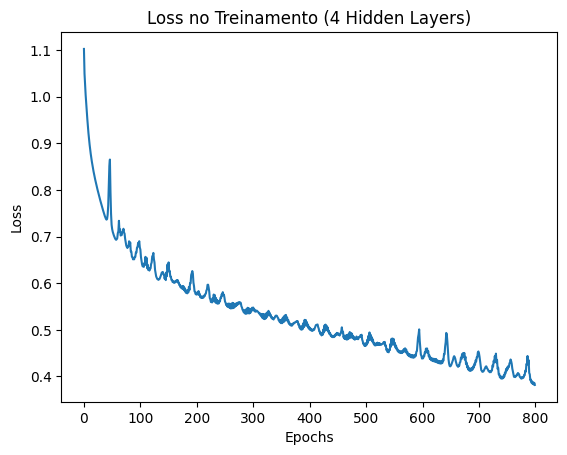

Accuracy final no teste: 0.72


In [14]:
class MLP:
    def __init__(self, input_dim, hidden_dims, output_dim, lr=0.01):
        self.layers = len(hidden_dims)
        self.params = {}
        dims = [input_dim] + hidden_dims + [output_dim]

        for i in range(len(dims)-1):
            self.params[f"W{i+1}"] = np.random.randn(dims[i], dims[i+1]) / np.sqrt(dims[i])
            self.params[f"b{i+1}"] = np.zeros((1, dims[i+1]))

        self.lr = lr

    # Ativações
    def relu(self, z): return np.maximum(0, z)
    def relu_deriv(self, z): return (z > 0).astype(float)
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # Forward
    def forward(self, X):
        self.cache = {"A0": X}
        for i in range(1, self.layers+1):
            self.cache[f"Z{i}"] = np.dot(self.cache[f"A{i-1}"], self.params[f"W{i}"]) + self.params[f"b{i}"]
            self.cache[f"A{i}"] = self.relu(self.cache[f"Z{i}"])
        # saída
        Z_out = np.dot(self.cache[f"A{self.layers}"], self.params[f"W{self.layers+1}"]) + self.params[f"b{self.layers+1}"]
        A_out = self.softmax(Z_out)
        self.cache[f"Z{self.layers+1}"] = Z_out
        self.cache[f"A{self.layers+1}"] = A_out
        return A_out

    # Loss
    def compute_loss(self, y, y_hat):
        return -np.mean(np.sum(y * np.log(y_hat + 1e-8), axis=1))

    # Backward
    def backward(self, y):
        m = y.shape[0]
        grads = {}
        # saída
        dZ = self.cache[f"A{self.layers+1}"] - y
        grads[f"dW{self.layers+1}"] = (1/m) * np.dot(self.cache[f"A{self.layers}"].T, dZ)
        grads[f"db{self.layers+1}"] = (1/m) * np.sum(dZ, axis=0, keepdims=True)

        for i in reversed(range(1, self.layers+1)):
            dA = np.dot(dZ, self.params[f"W{i+1}"].T)
            dZ = dA * self.relu_deriv(self.cache[f"Z{i}"])
            grads[f"dW{i}"] = (1/m) * np.dot(self.cache[f"A{i-1}"].T, dZ)
            grads[f"db{i}"] = (1/m) * np.sum(dZ, axis=0, keepdims=True)

        # update
        for i in range(1, self.layers+2):
            self.params[f"W{i}"] -= self.lr * grads[f"dW{i}"]
            self.params[f"b{i}"] -= self.lr * grads[f"db{i}"]

    # Treino
    def fit(self, X, y, epochs=300, X_val=None, y_val=None):
        losses = []
        for epoch in range(epochs):
            y_hat = self.forward(X)
            loss = self.compute_loss(y, y_hat)
            self.backward(y)
            losses.append(loss)

            if epoch % 50 == 0:
                preds = np.argmax(y_hat, axis=1)
                true = np.argmax(y, axis=1)
                acc = np.mean(preds == true)
                print(f"Epoch {epoch}, Loss {loss:.4f}, Train Acc {acc:.4f}")
        return losses

    def predict(self, X):
        y_hat = self.forward(X)
        return np.argmax(y_hat, axis=1)
    


mlp = MLP(input_dim=4, hidden_dims=[100, 80, 50, 30], output_dim=3, lr=0.1)
losses = mlp.fit(X_train, y_train, epochs=800)

plt.plot(losses)
plt.title("Loss no Treinamento (4 Hidden Layers)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

y_pred = mlp.predict(X_test)
y_true = np.argmax(y_test, axis=1)
accuracy = np.mean(y_pred == y_true)
print(f"Accuracy final no teste: {accuracy:.2f}")

